# Retail Sales Forecasting & Business Insights System

## Importing Libraries


In [1]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
%matplotlib inline

## Loading DataSets

In [2]:
train  = pd.read_csv("train - Walmart Sales Forecast.csv")
train.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [3]:
store = pd.read_csv("stores - Walmart Sales Forecast.csv")
store.head() 

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [4]:
features = pd.read_csv("features - Walmart Sales Forecast.csv")
features.head()

,Store,Date,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday
0,1,2010-02-05,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False
1,1,2010-02-12,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True
2,1,2010-02-19,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False
3,1,2010-02-26,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False
4,1,2010-03-05,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False


### Coverting Date into Datetime format 

In [5]:
train['Date'] = pd.to_datetime(train['Date'])
features['Date'] = pd.to_datetime(features['Date'])
df = train.merge(features, on=['Store', 'Date'], how='left')
df = df.merge(store, on='Store', how='left')
print(df.shape)
df.head()

(421570, 17)


,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,NaN,NaN,NaN,NaN,NaN,211.096358,8.106,False,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,NaN,NaN,NaN,NaN,NaN,211.242170,8.106,True,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,NaN,NaN,NaN,NaN,NaN,211.289143,8.106,False,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,NaN,NaN,NaN,NaN,NaN,211.319643,8.106,False,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,NaN,NaN,NaN,NaN,NaN,211.350143,8.106,False,A,151315


### Data Cleaning and EDA

In [6]:
markdown_cols = ['MarkDown1','MarkDown2','MarkDown3','MarkDown4','MarkDown5']
df[markdown_cols] = df[markdown_cols].fillna(0)
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday_x,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,MarkDown5,CPI,Unemployment,IsHoliday_y,Type,Size
0,1,1,2010-02-05,24924.50,False,42.31,2.572,0.0,0.0,0.0,0.0,0.0,211.096358,8.106,False,A,151315
1,1,1,2010-02-12,46039.49,True,38.51,2.548,0.0,0.0,0.0,0.0,0.0,211.242170,8.106,True,A,151315
2,1,1,2010-02-19,41595.55,False,39.93,2.514,0.0,0.0,0.0,0.0,0.0,211.289143,8.106,False,A,151315
3,1,1,2010-02-26,19403.54,False,46.63,2.561,0.0,0.0,0.0,0.0,0.0,211.319643,8.106,False,A,151315
4,1,1,2010-03-05,21827.90,False,46.50,2.625,0.0,0.0,0.0,0.0,0.0,211.350143,8.106,False,A,151315


In [7]:
df.isnull().sum()


Store           0
Dept            0
Date            0
Weekly_Sales    0
IsHoliday_x     0
Temperature     0
Fuel_Price      0
MarkDown1       0
MarkDown2       0
MarkDown3       0
MarkDown4       0
MarkDown5       0
CPI             0
Unemployment    0
IsHoliday_y     0
Type            0
Size            0
dtype: int64

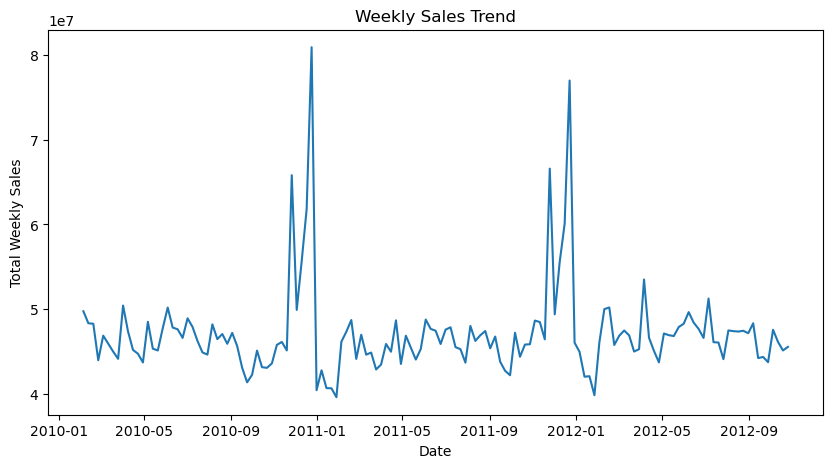

In [8]:
sales_trend = df.groupby('Date')['Weekly_Sales'].sum()
plt.figure(figsize=(10,5))
plt.plot(sales_trend.index, sales_trend.values)
plt.title("Weekly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Weekly Sales")
plt.show()


In [9]:
df['IsHoliday'] = df['IsHoliday_x']
df.drop(columns=['IsHoliday_x', 'IsHoliday_y'], inplace=True)

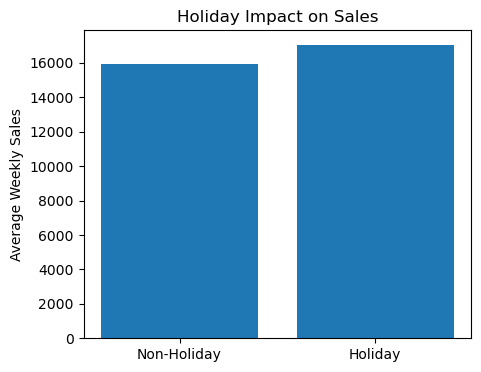

In [10]:
holiday_avg = df.groupby('IsHoliday')['Weekly_Sales'].mean()
plt.figure(figsize=(5,4))
plt.bar(['Non-Holiday','Holiday'], holiday_avg.values)
plt.title("Holiday Impact on Sales")
plt.ylabel("Average Weekly Sales")
plt.show()


### Feature Engineering 

In [11]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Week'] = df['Date'].dt.isocalendar().week.astype(int)
df['HasPromotion'] = (df[markdown_cols].sum(axis=1) > 0).astype(int)
df = df.sort_values(['Store', 'Date'])
df['Lag_1'] = df.groupby('Store')['Weekly_Sales'].shift(1)
df['Lag_4'] = df.groupby('Store')['Weekly_Sales'].shift(4)
df['Rolling_4'] = df.groupby('Store')['Weekly_Sales'].shift(1).rolling(4).mean()
df = df.dropna()
print(df.shape)
df.head()

(421390, 23)


,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,...,Type,Size,IsHoliday,Year,Month,Week,HasPromotion,Lag_1,Lag_4,Rolling_4
572,1,5,2010-02-05,32229.38,42.31,2.572,0.0,0.0,0.0,0.0,...,A,151315,False,2010,2,5,0,39954.04,24924.50,32305.9825
715,1,6,2010-02-05,5749.03,42.31,2.572,0.0,0.0,0.0,0.0,...,A,151315,False,2010,2,5,0,32229.38,50605.27,34132.2025
858,1,7,2010-02-05,21084.08,42.31,2.572,0.0,0.0,0.0,0.0,...,A,151315,False,2010,2,5,0,5749.03,13740.12,22918.1425
1001,1,8,2010-02-05,40129.01,42.31,2.572,0.0,0.0,0.0,0.0,...,A,151315,False,2010,2,5,0,21084.08,39954.04,24754.1325
1144,1,9,2010-02-05,16930.99,42.31,2.572,0.0,0.0,0.0,0.0,...,A,151315,False,2010,2,5,0,40129.01,32229.38,24797.8750


### Model Training

In [12]:
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

In [13]:
le = LabelEncoder()
df['Type'] = le.fit_transform(df['Type'])
df.head()

,Store,Dept,Date,Weekly_Sales,Temperature,Fuel_Price,MarkDown1,MarkDown2,MarkDown3,MarkDown4,...,Type,Size,IsHoliday,Year,Month,Week,HasPromotion,Lag_1,Lag_4,Rolling_4
572,1,5,2010-02-05,32229.38,42.31,2.572,0.0,0.0,0.0,0.0,...,0,151315,False,2010,2,5,0,39954.04,24924.50,32305.9825
715,1,6,2010-02-05,5749.03,42.31,2.572,0.0,0.0,0.0,0.0,...,0,151315,False,2010,2,5,0,32229.38,50605.27,34132.2025
858,1,7,2010-02-05,21084.08,42.31,2.572,0.0,0.0,0.0,0.0,...,0,151315,False,2010,2,5,0,5749.03,13740.12,22918.1425
1001,1,8,2010-02-05,40129.01,42.31,2.572,0.0,0.0,0.0,0.0,...,0,151315,False,2010,2,5,0,21084.08,39954.04,24754.1325
1144,1,9,2010-02-05,16930.99,42.31,2.572,0.0,0.0,0.0,0.0,...,0,151315,False,2010,2,5,0,40129.01,32229.38,24797.8750


In [14]:
features = [
    'Store','Type','Size','Temperature','Fuel_Price',
    'CPI','Unemployment','IsHoliday',
    'Year','Month','Week','HasPromotion',
    'Lag_1','Lag_4','Rolling_4'
]

In [15]:
x = df[features]
y = df['Weekly_Sales']

In [16]:
split = int(len(df) * 0.8)
x_train, x_test = x.iloc[:split], x.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

In [17]:
lr = LinearRegression()
lr.fit(x_train, y_train)
lr_pred = lr.predict(x_test)
lr.score(x_test,y_test)

0.2062810524322939

In [18]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=40,
    n_jobs=-1,
    max_depth=10
)
rf.fit(x_train, y_train)
rf_pred = rf.predict(x_test)
rf.score(x_test, y_test)


0.35903988413480037

### Model Evaluation and Selection

In [19]:
from sklearn.model_selection import GridSearchCV,TimeSeriesSplit
from sklearn.linear_model import LinearRegression,Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

In [20]:
tscv = TimeSeriesSplit(n_splits=5)

In [21]:
models = {
    "LinearRegression": {
        "model": LinearRegression(),
        "params": {} 
    },

    "Lasso": {
        "model": Lasso(max_iter=1000),
        "params": {
            "alpha": [0.00001, 0.0001, 0.001, 0.01, 1]
        }
    },

    "RandomForestRegressor":{
        "model" : RandomForestRegressor(),
        "params" : {
            "max_depth" : [10],
            "n_estimators" : [100],
            "random_state" : [40],
            "n_jobs" : [-1]
        }
    },

    "DecisionTree": {
        "model": DecisionTreeRegressor(random_state=42),
        "params": {
            "max_depth": [5, 10, 15, None],
            "min_samples_split": [2, 5, 10]
        }
    },

}
results = []

In [22]:
for model_name, model_info in models.items():
    print(f"\nTraining {model_name}...")

    grid = GridSearchCV(
        estimator=model_info["model"],
        param_grid=model_info["params"],
        cv=tscv,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )
    grid.fit(x_train, y_train)
    best_model = grid.best_estimator_
    y_pred = best_model.predict(x_test)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    results.append({
        "Model": model_name,
        "Best Parameters": grid.best_params_,
        "RMSE": rmse,
        "R2 Score": r2
    })
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by="RMSE")
results_df


Training LinearRegression...

Training Lasso...


C:\Users\vedpa\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.146e+11, tolerance: 1.870e+10
  model = cd_fast.enet_coordinate_descent(



Training RandomForestRegressor...

Training DecisionTree...


,Model,Best Parameters,RMSE,R2 Score
2,RandomForestRegressor,"{'max_depth': 10, 'n_estimators': 100, 'n_jobs...",14903.654866,0.359040
3,DecisionTree,"{'max_depth': 5, 'min_samples_split': 2}",16240.073810,0.238936
1,Lasso,{'alpha': 1},16584.587824,0.206303
0,LinearRegression,{},16584.815924,0.206281


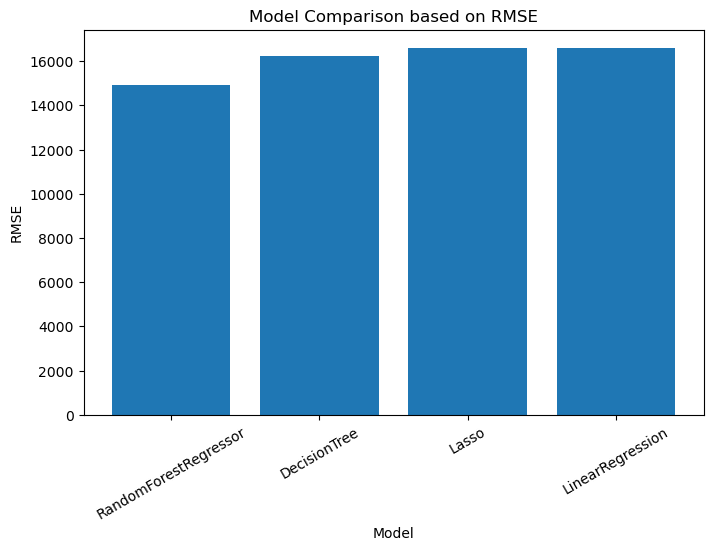

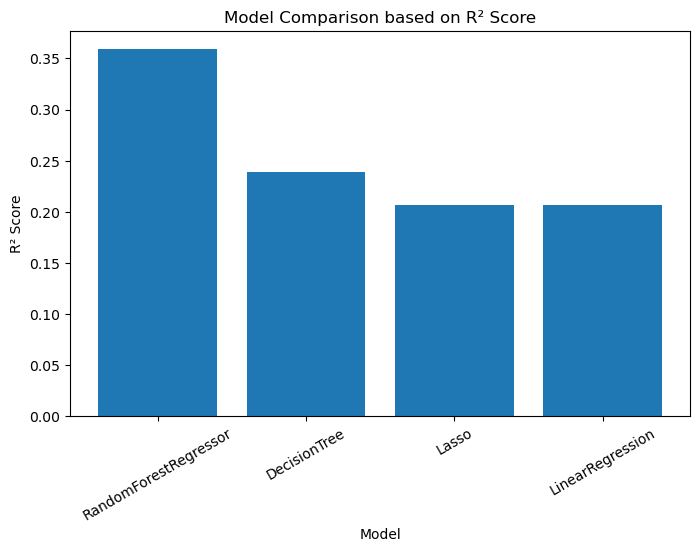

In [23]:
models = results_df['Model']
rmse = results_df['RMSE']
r2 = results_df['R2 Score']
plt.figure(figsize=(8, 5))
plt.bar(models, rmse)
plt.title("Model Comparison based on RMSE")
plt.xlabel("Model")
plt.ylabel("RMSE")
plt.xticks(rotation=30)
plt.show()
plt.figure(figsize=(8, 5))
plt.bar(models, r2)
plt.title("Model Comparison based on R² Score")
plt.xlabel("Model")
plt.ylabel("R² Score")
plt.xticks(rotation=30)
plt.show()


In [24]:
best_index = np.argmin([r['RMSE'] for r in results])
best_model_name = results[best_index]['Model']
best_model_params = results[best_index]['Best Parameters']
print("Best Model:", best_model_name)
print("Best Params:", best_model_params)
if best_model_name == 'LinearRegression':
    best_model = LinearRegression(**best_model_params)
elif best_model_name == 'Lasso':
    best_model = Lasso(max_iter=5000, **best_model_params)
elif best_model_name == 'DecisionTree':
    best_model = DecisionTreeRegressor(random_state=42, **best_model_params)
elif best_model_name == 'RandomForest':
    best_model = RandomForestRegressor(random_state=42, **best_model_params)
best_model.fit(x_train, y_train)
best_pred = best_model.predict(x_test)

Best Model: RandomForestRegressor
Best Params: {'max_depth': 10, 'n_estimators': 100, 'n_jobs': -1, 'random_state': 40}


In [26]:
import os
import pandas as pd

os.makedirs("outputs", exist_ok=True)

final_output = x_test.copy()
final_output["Actual_Sales"] = y_test.values
final_output["Predicted_Sales"] = best_pred

output_path = "outputs/final_predictions.xlsx"

with pd.ExcelWriter(output_path, engine="openpyxl") as writer:
    final_output.to_excel(writer, index=False, sheet_name="Predictions")

    worksheet = writer.sheets["Predictions"]

    # Auto-adjust column width
    for column_cells in worksheet.columns:
        length = max(len(str(cell.value)) if cell.value is not None else 0 for cell in column_cells)
        worksheet.column_dimensions[column_cells[0].column_letter].width = length + 2

print("Excel file exported successfully:", output_path)


Excel file exported successfully: outputs/final_predictions.xlsx
